In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import arviz as az
import arviz_plots as azp

--- ベイズ A/B テスト結果 ---
ad の事後平均 CVR: 2.5549%
psa の事後平均 CVR: 1.7892%
広告グループ（ad）が対照群（psa）を上回っている確率: 100.0000%


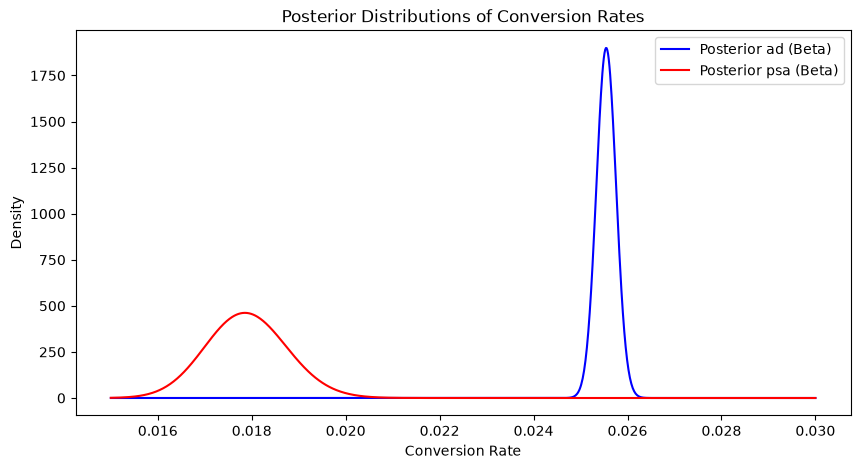

In [2]:
#Beta分布（事前分布）×二項分布(尤度)=Beta分布（事後分布）をScipyで実装
n_ad = 550154 + 14423  # adの総数
x_ad = 14423           # adのコンバージョン数

n_psa = 23104 + 420    # psaの総数
x_psa = 420            # psaのコンバージョン数

alpha_prior = 1
beta_prior = 1

alpha_ad_post = alpha_prior + x_ad
beta_ad_post = beta_prior + (n_ad - x_ad)

alpha_psa_post = alpha_prior + x_psa
beta_psa_post = beta_prior + (n_psa - x_psa)

size = 100000
samples_ad = stats.beta.rvs(alpha_ad_post, beta_ad_post, size=size)
samples_psa = stats.beta.rvs(alpha_psa_post, beta_psa_post, size=size)

prob_ad_better = np.mean(samples_ad > samples_psa)

print("--- ベイズ A/B テスト結果 ---")
print(f"ad の事後平均 CVR: {np.mean(samples_ad):.4%}")
print(f"psa の事後平均 CVR: {np.mean(samples_psa):.4%}")
print(f"広告グループ（ad）が対照群（psa）を上回っている確率: {prob_ad_better:.4%}")

plt.figure(figsize=(10, 5))
x = np.linspace(0.015, 0.03, 1000)
plt.plot(x, stats.beta.pdf(x, alpha_ad_post, beta_ad_post), label="Posterior ad (Beta)", color="blue")
plt.plot(x, stats.beta.pdf(x, alpha_psa_post, beta_psa_post), label="Posterior psa (Beta)", color="red")
plt.title("Posterior Distributions of Conversion Rates")
plt.xlabel("Conversion Rate")
plt.ylabel("Density")
plt.legend()
plt.show()

In [3]:
#PyMC(MCMC)で実装
df = pd.read_csv("../data/marketing_AB.csv")

df["group_idx"] = df["test group"].map({"psa":0, "ad":1})
converted = df["converted"].astype(int).values
group_idx = df["group_idx"].values

with pm.Model() as model:
    p = pm.Beta("p", alpha=1, beta=1, shape=2)
    obs = pm.Bernoulli("obs", p=p[group_idx], observed=converted)

    diff = pm.Deterministic("diff", p[1]-p[0])
    relation = pm.Deterministic("relation", p[1]/p[0])

    trace = pm.sample(draws=2000, tune=2000, return_inferencedata=True, random_seed=42)



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


/home/manaty/bayesian-A-B-testing/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 157 seconds.


In [4]:
print("---サンプリング結果の要約---")
az.summary(trace, var_names=["p", "diff", "relation"])


---サンプリング結果の要約---


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p[0],0.01789,0.00087,0.017,0.019,8477,5443,1.00,9.4e-06,6.6e-06
p[1],0.025552,0.000208,0.025,0.026,8109,5827,1.00,2.3e-06,1.6e-06
diff,0.00766,0.00089,0.0062,0.0091,8613,5575,1.00,9.6e-06,6.7e-06
relation,1.432,0.071,1.3,1.5,8581,5705,1.00,0.00076,0.00055


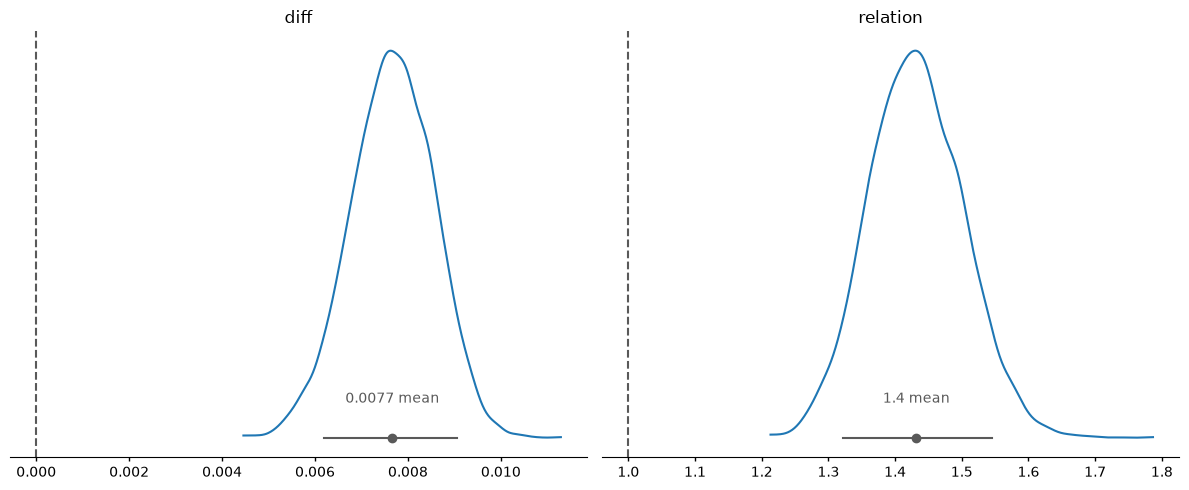

In [5]:
pc = azp.plot_dist(
    trace, 
    var_names=["diff", "relation"], 
    figure_kwargs={"figsize": (12, 5)}
)


azp.add_lines(pc, values={"diff": 0, "relation": 1})

plt.tight_layout()
plt.show()

In [13]:
p_psa_samples = trace.posterior["p"].sel(p_dim_0=0).values.flatten()
p_ad_samples = trace.posterior["p"].sel(p_dim_0=1).values.flatten()

loss_ad = np.where(p_psa_samples > p_ad_samples, p_psa_samples- p_ad_samples, 0)

expected_loss_ad = np.mean(loss_ad)

print("---期待損失の分析結果---")
print(f"ad(広告グループ）を採用した際の期待損失:{expected_loss_ad:.6%}")

threshold = 0.00005

if expected_loss_ad < threshold:
    print(f"\n結果: 期待損失 ({expected_loss_ad:.6%}) が、しきい値 ({threshold:.5%}) を下回りました！")
    print("安全にテストを終了し、広告（ad）を正式に全面導入してOKです。")
else:
    print(f"\n結果: まだ期待損失が基準を超えています。データが不足しているか、差が僅かです。テストを継続してください。")

---期待損失の分析結果---
ad(広告グループ）を採用した際の期待損失:0.000000%

結果: 期待損失 (0.000000%) が、しきい値 (0.00500%) を下回りました！
安全にテストを終了し、広告（ad）を正式に全面導入してOKです。
